# Rectangular Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.importers import STEPImporter
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.rectangular_waveguide import RWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [2]:
# import step file
maxh = 0.03  # Mesh size
rwg = STEPImporter(r"./rectangular_waveguide.step", auto_build=False) # auto_build false so as not 
                                                                      # to build the geo and mesh until after
                                                                      # defining ports

rwg = STEPImporter(r"./rectangular_waveguide.step", auto_build=True, maxh=0.02)
rwg.name_faces_by_position(axis='Z')
rwg.generate_mesh(maxh=0.04)

print(f"Mesh DOFs: ~{rwg.mesh.nv} vertices")
rwg.show('mesh')

Mesh DOFs: ~44 vertices


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

## 2. Analytical Solution

Compute the analytical Z-parameters for comparison with numerical results.

In [3]:
# Waveguide parameters
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm

analytical = RWGAnalytical(a=a, L=L)
frequencies = np.linspace(1.0, 3.0, 100) * 1e9

## 3. Full-Order Numerical Solution

Run a full-order finite element frequency sweep.

In [9]:
# Create solver with wave impedance enabled
fds = FrequencyDomainSolver(rwg, order=3)
fds.assemble_matrices(nmodes=1)

print(f"Number of ports: {len(fds.port_modes)}")

# Print port info
fds.print_port_info()


Structure Topology
Type: Single structure
Domains (1): ['default']
Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  default: ['port1 (external, input)', 'port2 (external, output)']
  port1 mode 0: kc=31.4160, type=TE, alignment=0.0000, degeneracy=1
  port2 mode 0: kc=31.4160, type=TE, alignment=0.0000, degeneracy=1

Assembling matrices for domain: default
  FES ndof: 2548
  K shape: (2548, 2548)
  B shape: (2548, 2)
Number of ports: 2

Port Information

Port: port1 [external (input)]
  Adjacent domains: ['default']
  Normal: [ 0.  0. -1.]
  Orientation factor: 1.0
  Mode 0: fc = 1.4990 GHz

Port: port2 [external (output)]
  Adjacent domains: ['default']
  Normal: [0. 0. 1.]
  Orientation factor: -1.0
  Mode 0: fc = 1.4990 GHz


In [11]:
fds.port_solver.port_orientation_factors

{'port1': np.float64(1.0), 'port2': np.float64(-1.0)}


Structure Topology
Type: Single structure
Domains (1): ['default']
Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  default: ['port1 (external, input)', 'port2 (external, output)']
  port1 mode 0: kc=31.4160, type=TE, alignment=0.0000, degeneracy=1
  port2 mode 0: kc=31.4160, type=TE, alignment=0.0000, degeneracy=1

Assembling matrices for domain: default
  FES ndof: 2548
  K shape: (2548, 2548)
  B shape: (2548, 2)

Solving domain: default


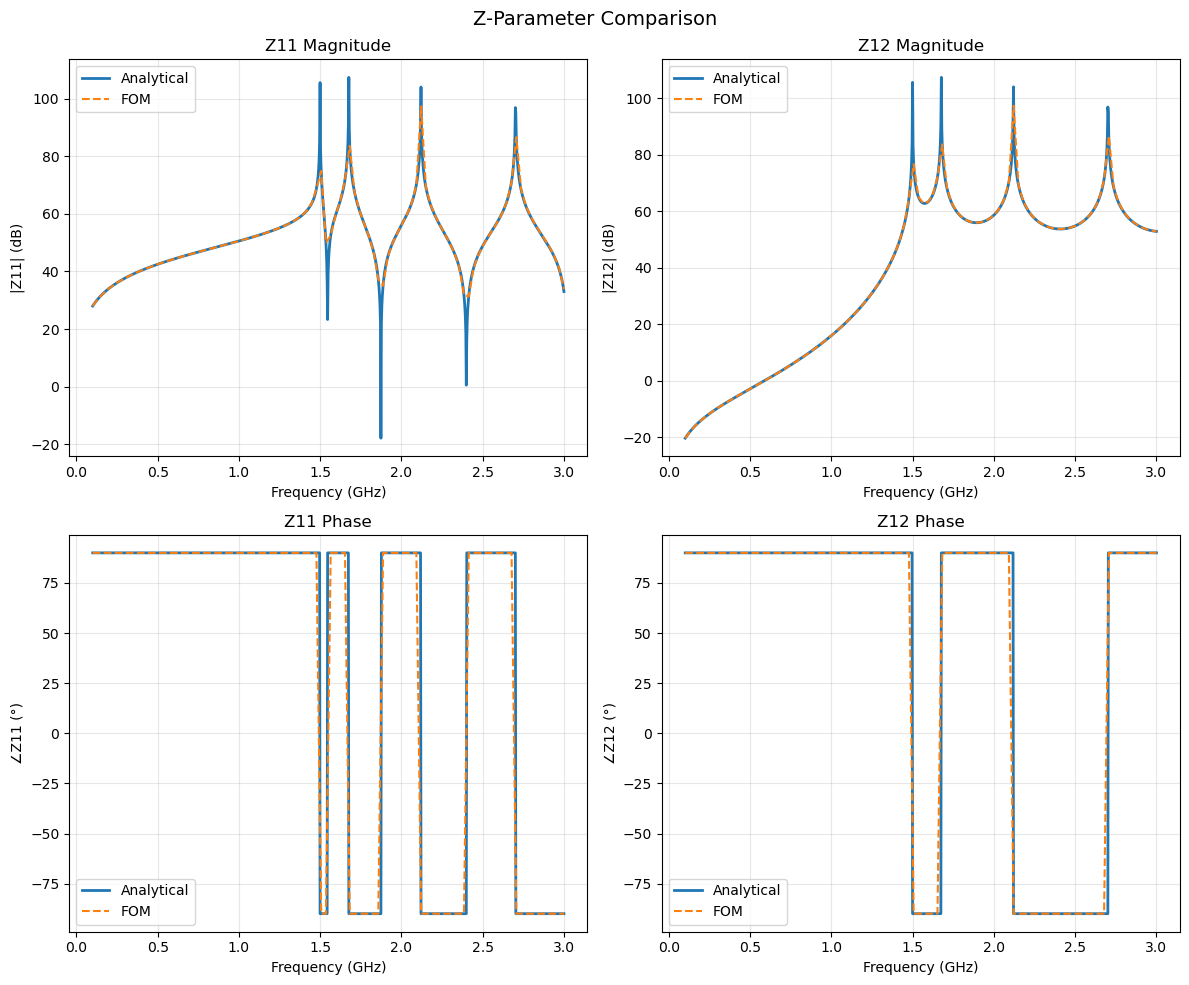

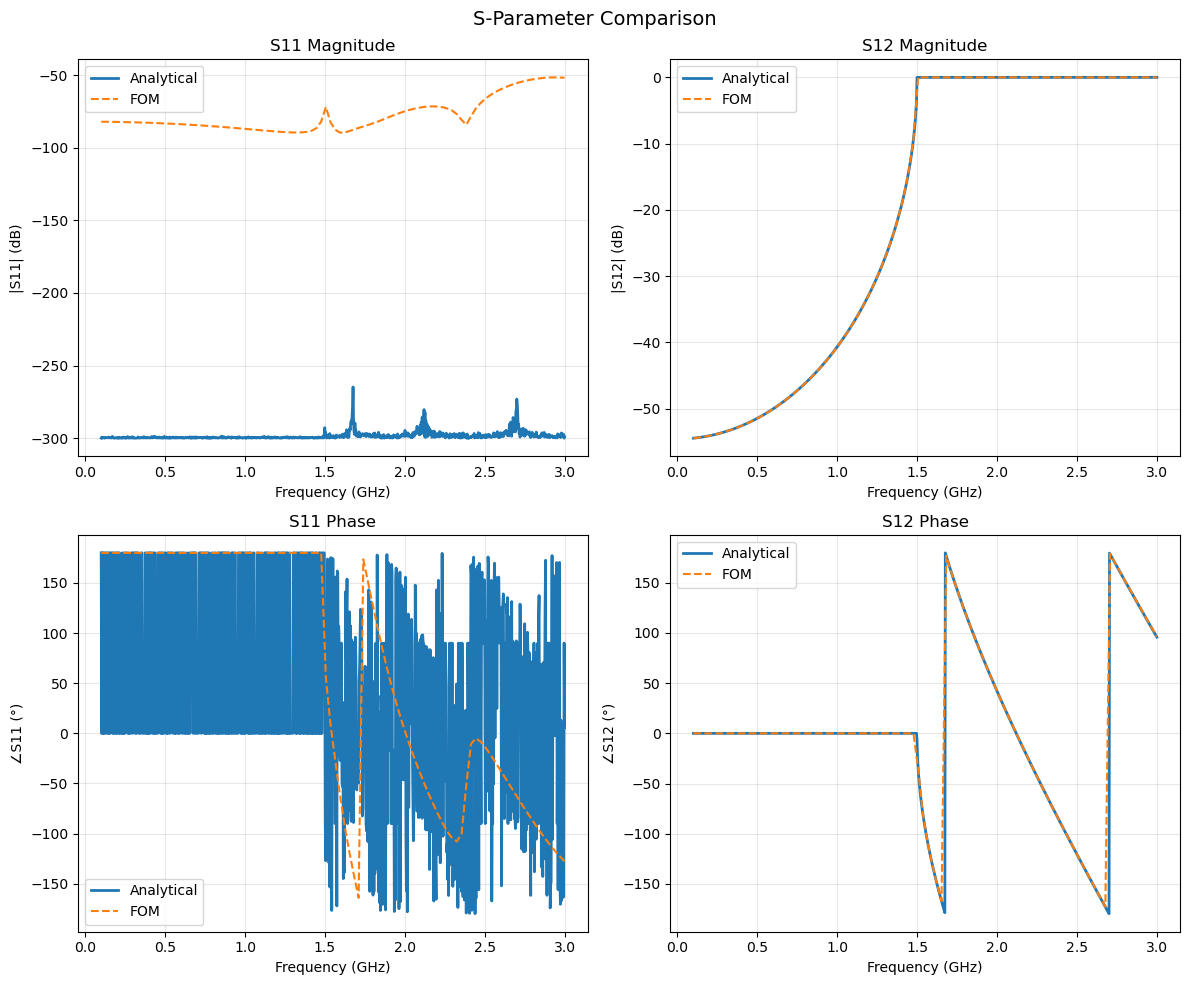

(<Figure size 1200x1000 with 4 Axes>,
 {'S11_mag': <Axes: title={'center': 'S11 Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S11| (dB)'>,
  'S11_phase': <Axes: title={'center': 'S11 Phase'}, xlabel='Frequency (GHz)', ylabel='∠S11 (°)'>,
  'S12_mag': <Axes: title={'center': 'S12 Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S12| (dB)'>,
  'S12_phase': <Axes: title={'center': 'S12 Phase'}, xlabel='Frequency (GHz)', ylabel='∠S12 (°)'>})

In [13]:
# Solve with S-parameter computation
fds = FrequencyDomainSolver(rwg, order=3)
fds.assemble_matrices(nmodes=1)
fds.solve(0.1, 3, 100, store_snapshots=True)

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(0.1, 3.0, 1000) * 1e9
plot_z_comparison([analytical, fds], frequencies=frequencies)
plot_s_comparison([analytical, fds], frequencies=frequencies)

In [14]:
fds.plot_port_mode('port2', mode=0, component='abs')


Port Mode: port2 [external (output)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

In [15]:
# Plot with clipping plane
fds.plot_field(
    freq_idx=25,  # Middle frequency
    component='abs',
    clipping={'x': 0, 'y': 0, 'z': 1}  # Clip to see inside
)


Field visualization at f = 0.8323 GHz
Domain: default
Excitation: port1, mode 0
Plotting: |E| (abs)


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

In [17]:
# # Plot field along waveguide axis
# fig, ax = fds.plot_field_along_line(
#     freq_idx=25,
#     start=(a/2, a/2, 0),
#     end=(a/2, a/2, L),
#     component='abs'
# )
# plt.show()

## 4. Model Order Reduction

Build a reduced-order model using Proper Orthogonal Decomposition (POD).

In [10]:
# Build reduced-order model
rom = ModelOrderReduction(solver.M, solver.K, solver.B)
A_r, B_r, W = rom.reduce(solver.snapshots, tol=1e-6)

print(f"Original dimension: {solver.M.shape[0]}")
print(f"Reduced dimension: {rom.r}")
print(f"Compression ratio: {solver.M.shape[0] / rom.r:.1f}x")

Original dimension: 6660
Reduced dimension: 15
Compression ratio: 444.0x


In [11]:
# Create wave impedance function from port solver
def wave_impedance_func(freq):
    return solver.port_solver.get_wave_impedance_matrix(freq)

# Solve ROM
Z_reduced = rom.solve_reduced(frequencies, wave_impedance_func=wave_impedance_func)

print(f"ROM solved at {len(frequencies)} points")
print(f"Z shape: {Z_reduced['Z'].shape}")
print(f"S shape: {Z_reduced['S'].shape}")

ROM solved at 100 points
Z shape: (100, 2, 2)
S shape: (100, 2, 2)


## 5. Comparison and Plotting

Compare Z-parameters from analytical, full FEM, and ROM solutions.

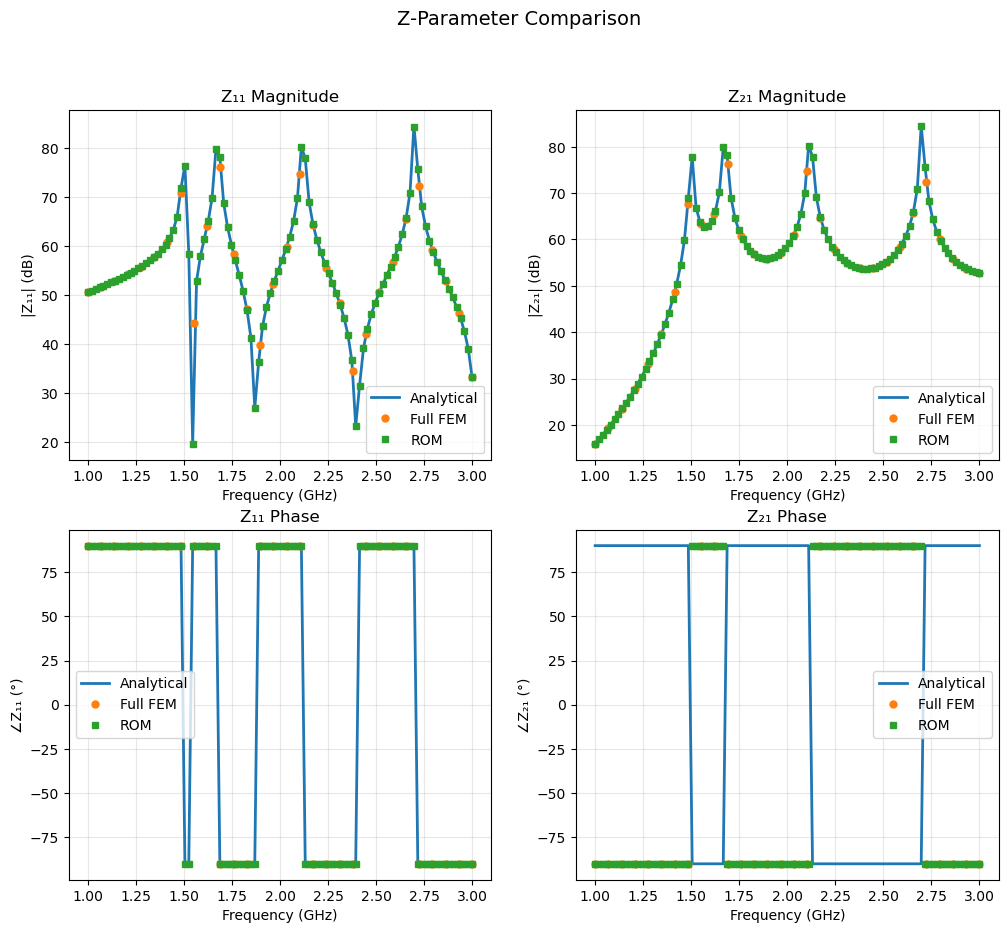

In [12]:
plotter = ZParameterPlotter(figsize=(12, 10))
plotter.setup_figure()
plotter.plot_comparison(Z_analytical, Z_full, Z_reduced)
plt.suptitle('Z-Parameter Comparison', fontsize=14)
plt.show()

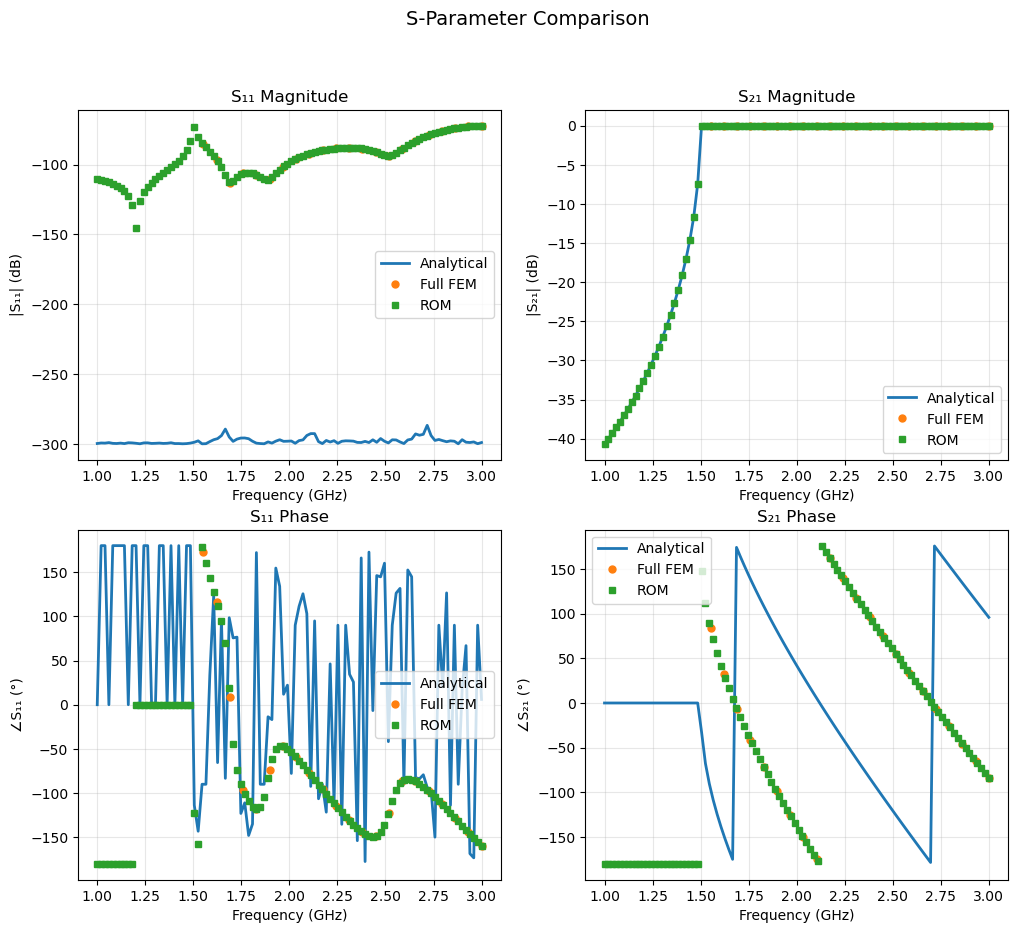

In [13]:
plotter = SParameterPlotter(figsize=(12, 10))
plotter.setup_figure()
plotter.plot_comparison(S_analytical, S_full, Z_reduced)
plt.suptitle('S-Parameter Comparison', fontsize=14)
plt.show()

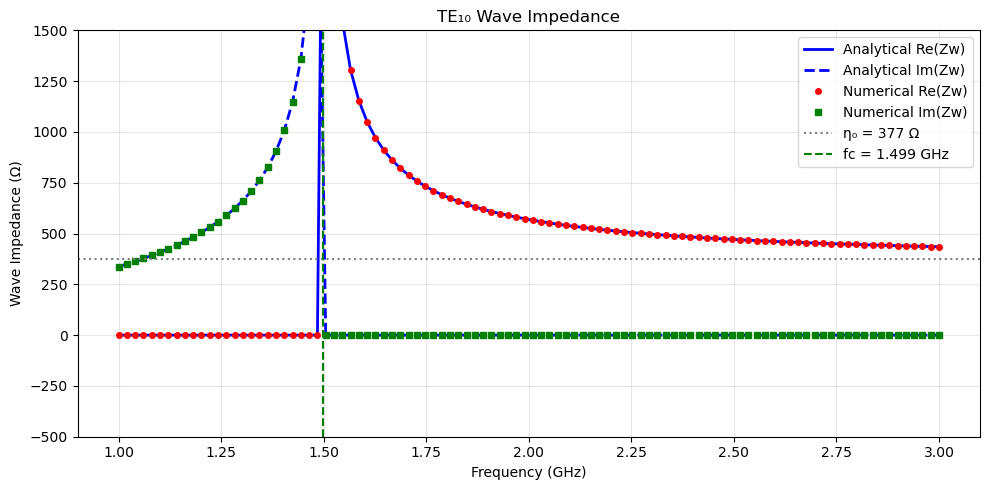

In [14]:
ports = list(solver.port_modes.keys())
Zw_numerical = np.array([solver.port_solver.get_wave_impedance(ports[0], 0, f) for f in frequencies])
Zw_analytical = analytical.wave_impedance(frequencies)

# Plot
fig, ax = WaveImpedancePlotter.quick_plot(
    frequencies, Zw_analytical, Zw_numerical,
    cutoff_freq=analytical.fc,
    title='TE₁₀ Wave Impedance'
)
plt.show()

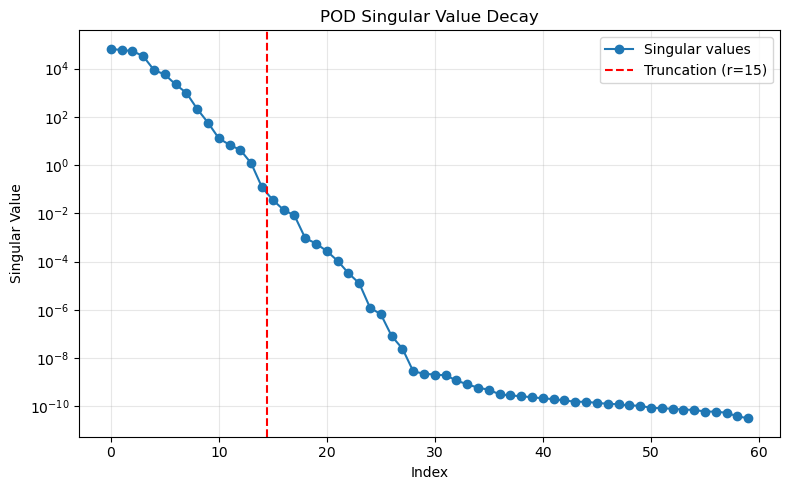

In [15]:
# Singular value decay plot
fig2, ax2 = plt.subplots(figsize=(8, 5))

ConvergencePlotter.plot_singular_values(
    rom._singular_values,
    truncation_rank=rom.r,
    ax=ax2
)

plt.title('POD Singular Value Decay')
plt.tight_layout()
plt.show()

## 6. Error Analysis

Quantify the error between numerical solutions and the analytical reference.

In [16]:
# ROM error
Z_ana_rom = analytical.z_parameters(Z_reduced['frequencies'])
Z11_rom = Z_reduced['Z'][:, 0, 0]
Z11_ana_rom = Z_ana_rom['Z11']

rel_error_rom = np.abs(Z11_rom - Z11_ana_rom) / np.abs(Z11_ana_rom)

print("ROM vs Analytical:")
print(f"   Mean relative error: {np.mean(rel_error_rom) * 100:.2f}%")
print(f"   Max relative error:  {np.max(rel_error_rom) * 100:.2f}%")

ROM vs Analytical:
   Mean relative error: 0.14%
   Max relative error:  2.10%


## 7. Eigenfrequency Comparison

Compare eigenfrequencies from the ROM with analytical values.

In [17]:
# Get ROM eigenfrequencies
eigs_rom = rom.get_eigenvalues()
freqs_rom = np.sqrt(np.abs(eigs_rom)) / (2 * np.pi)
freqs_rom_ghz = freqs_rom / 1e9

print("ROM eigenfrequencies (GHz):")
for i, f in enumerate(sorted(freqs_rom_ghz)[:10]):
    print(f"   Mode {i + 1}: {f:.4f} GHz")

ROM eigenfrequencies (GHz):
   Mode 1: 1.4990 GHz
   Mode 2: 1.6759 GHz
   Mode 3: 2.1199 GHz
   Mode 4: 2.7024 GHz
   Mode 5: 2.9981 GHz
   Mode 6: 3.0028 GHz
   Mode 7: 3.3523 GHz
   Mode 8: 4.0382 GHz
   Mode 9: 4.4474 GHz
   Mode 10: 4.7955 GHz


## Summary

This analysis demonstrated:
- **Geometry creation** for a rectangular waveguide
- **Full-order FEM** frequency domain analysis
- **Model order reduction** using POD with significant compression
- **Validation** against analytical solutions

The ROM provides accurate results with substantially reduced computational cost.

In [18]:
# Optional: Save figures to files
# Uncomment to save

# fig.savefig('rwg_z_parameters.png', dpi=150, bbox_inches='tight')
# fig2.savefig('rwg_singular_values.png', dpi=150, bbox_inches='tight')
# print("Figures saved!")